In [71]:
#Preprocessing
#import some important libraries for EDA
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_excel('flood_data.xlsx') # Load the data set

df.head()# first five rows of the datset

df.info()

# To detect the problem in data, we only need the numeric value in that column
mask = pd.to_numeric(df["Water_Discharge"], errors='coerce').isna() & df["Water_Discharge"].notna()
problematic = df.loc[mask, "Water_Discharge"]
print(problematic.unique())# see unique problem values

# Here we check the unneccessory values in the column of Minimum Temperature
mask = pd.to_numeric(df["Minimum_Temperature"], errors='coerce').isna() & df["Minimum_Temperature"].notna()
problematic = df.loc[mask, "Minimum_Temperature"]
# Show row numbers with values
print(problematic.to_string())

# here also check the unneccessory values in the column of Maximum Temperature
mask = pd.to_numeric(df["Maximum_Temperature"], errors='coerce').isna() & df["Maximum_Temperature"].notna()
problematic = df.loc[mask, "Maximum_Temperature"]
print(problematic.to_string())# see first 20 unique problem values

# here also check the unneccessory values in the column of Rainfall
mask = pd.to_numeric(df["Rainfall"], errors='coerce').isna() & df["Rainfall"].notna()
problematic = df.loc[mask, "Rainfall"]
print(problematic.to_string())# see first 20 unique problem values

# Replace non-numeric Rainfall values (found in previous cell) with 0.05
# Recreate the same mask
mask = pd.to_numeric(df["Rainfall"], errors='coerce').isna() & df["Rainfall"].notna()

# Replace problematic values with 0.05
df.loc[mask, "Rainfall"] = 0.05

# Convert the column to numeric type
df["Rainfall"] = pd.to_numeric(df["Rainfall"])


def clean_temperature_column(series):
    # 1️⃣ Convert to string
    s = series.astype(str)

    # 2️⃣ Replace non-breaking spaces (\xa0), normal spaces, and other invisible chars
    s = s.str.replace(u'\xa0', '', regex=False)
    s = s.str.replace(' ', '', regex=False)
    s = s.str.replace('\t', '', regex=False)

    # 3️⃣ Remove any non-numeric characters except digits, dot, or minus
    s = s.str.replace(r'[^0-9\.\-]', '', regex=True)

    # 4️⃣ Convert to float safely
    return pd.to_numeric(s, errors='coerce')

# Apply to your numeric columns
cols = ["Maximum_Temperature","Minimum_Temperature","Water_Discharge"]
for c in cols:
    df[c] = clean_temperature_column(df[c])

df=df.dropna(subset=['Minimum_Temperature']) #Removing rows with NaN in them, i.e. we converted text to NaN. We only want numeric values

df['Rainfall']=df['Rainfall'].fillna(0.05)# we fill the Null values with 0.05 replacing the string Trace which means a very low value

#percentage=(df['Minimum_Temperature']<5).mean()*100 #Data Exploration

#(df['Maximum_Temperature']<10).sum() #Data Exploration

# in this cell we remove those value which have no meaning for our data and create a new coloumn Temp_diff
df['Minimum_Temperature']=df['Minimum_Temperature'].apply(lambda x: 5 if x<5 else x)
df['Maximum_Temperature']=df['Maximum_Temperature'].apply(lambda x: 10 if x<10 else x)
df['Water_Discharge']=df['Water_Discharge'].apply(lambda x: 50 if x<50 else x)
df['Water_Discharge']=df['Water_Discharge'].apply(lambda x: 4000 if x>4000 else x)
df['Average_Temperature']=df['Average_Temperature'].apply(lambda x:7 if x<5 else x)
df['Temp_Diff'] =df['Maximum_Temperature'] - df['Minimum_Temperature']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 4018 non-null   datetime64[ns]
 1   Maximum_Temperature  4018 non-null   object        
 2   Minimum_Temperature  4018 non-null   object        
 3   Average_Temperature  4018 non-null   float64       
 4   Rainfall             4018 non-null   object        
 5   Water_Discharge      4018 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 188.5+ KB
['527.0\xa0' '476.1\xa0' '434.3\xa0' '444.9\xa0' '472.1\xa0' '474.4\xa0'
 '440.0\xa0' '416.6\xa0' '404.0\xa0' '401.2\xa0' '354.7\xa0' '290.1\xa0'
 '270.3\xa0' '263.3\xa0' '291.7\xa0' '345.2\xa0' '339.6\xa0' '301.7\xa0'
 '295.5\xa0' '265.8\xa0' '252.4\xa0' '263.0\xa0' '218.3\xa0' '207.8\xa0'
 '197.6\xa0' '181.3\xa0' '267.5\xa0' '263.8\xa0' '268.0\xa0' '250.6\xa0'


In [72]:
df.describe()

,Date,Maximum_Temperature,Minimum_Temperature,Average_Temperature,Rainfall,Water_Discharge,Temp_Diff
count,4018,4018.000000,4018.000000,4018.000000,4018.000000,4018.000000,4018.000000
mean,2017-07-01 12:00:00,28.753863,16.180687,22.292399,1.267086,797.352576,12.573176
min,2012-01-01 00:00:00,10.000000,5.000000,5.000000,0.000000,50.000000,-0.600000
25%,2014-10-01 06:00:00,22.000000,8.000000,15.000000,0.000000,268.925000,10.300000
50%,2017-07-01 12:00:00,29.250000,17.000000,23.000000,0.000000,452.550000,13.500000
75%,2020-03-31 18:00:00,36.000000,23.875000,29.750000,0.000000,1254.000000,16.000000
max,2022-12-31 00:00:00,48.000000,33.000000,37.850000,80.000000,4000.000000,24.300000
std,NaN,8.604433,7.994586,8.155675,5.271671,694.495780,5.142053


<Axes: xlabel='Maximum_Temperature', ylabel='Water_Discharge'>

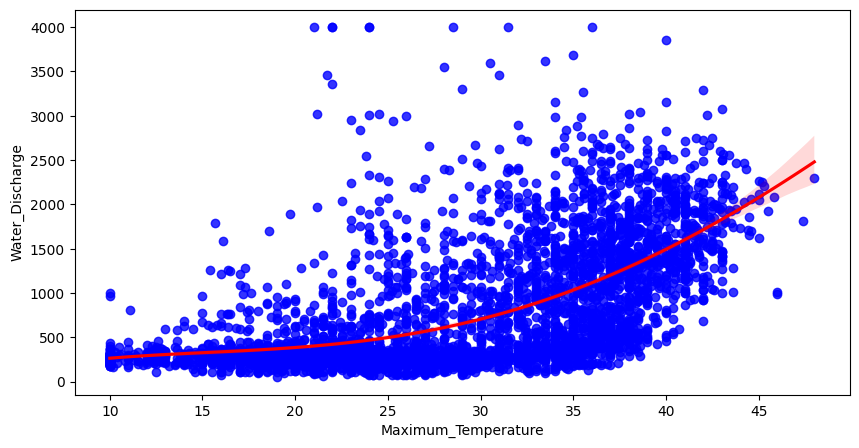

In [73]:
#Data Exploration using plot
plt.figure(figsize=(10,5))
sns.regplot(
    x=df['Maximum_Temperature'],
    y=df['Water_Discharge'],
    order=4,
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}  # <-- change slope (line) color here
)

<Axes: xlabel='Rainfall', ylabel='Water_Discharge'>

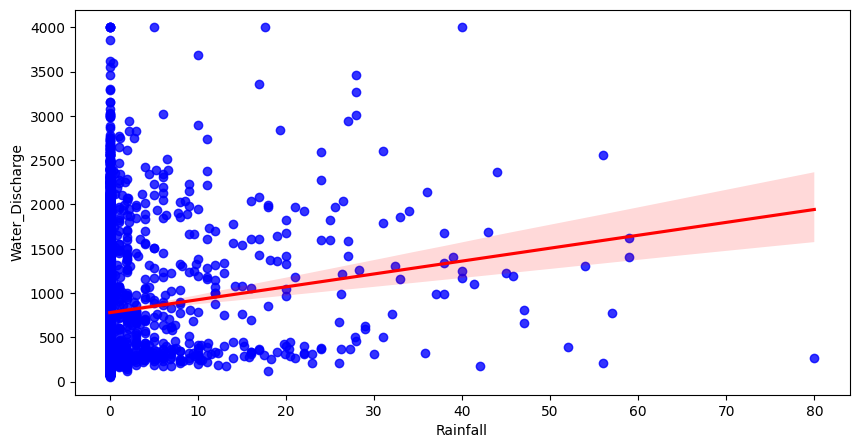

In [74]:
plt.figure(figsize=(10,5))
sns.regplot(
    x=df['Rainfall'],
    y=df['Water_Discharge'],
    scatter_kws={'color':'Blue'},
    line_kws={'color':'Red'}
)

In [75]:
#Using day and month to find seasonality
df['Day']=df['Date'].dt.day
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year

In [76]:
df=df.drop('Date',axis=1)

In [77]:
df.head()

,Maximum_Temperature,Minimum_Temperature,Average_Temperature,Rainfall,Water_Discharge,Temp_Diff,Day,Month,Year
0,22.0,5.0,11.35,0.00,185.5,17.0,1,1,2012
1,20.5,5.0,10.65,0.00,235.1,15.5,2,1,2012
2,20.8,5.0,10.90,0.00,235.0,15.8,3,1,2012
3,15.0,5.0,8.35,0.00,247.4,10.0,4,1,2012
4,15.0,5.4,10.20,0.05,267.9,9.6,5,1,2012


In [78]:
df=df[['Year','Month','Day','Maximum_Temperature','Minimum_Temperature','Rainfall','Average_Temperature','Water_Discharge','Temp_Diff']]

In [79]:
df.head()

,Year,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff
0,2012,1,1,22.0,5.0,0.00,11.35,185.5,17.0
1,2012,1,2,20.5,5.0,0.00,10.65,235.1,15.5
2,2012,1,3,20.8,5.0,0.00,10.90,235.0,15.8
3,2012,1,4,15.0,5.0,0.00,8.35,247.4,10.0
4,2012,1,5,15.0,5.4,0.05,10.20,267.9,9.6


In [54]:
df=df.drop('Year',axis=1)

In [55]:
df.head()

,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff
0,1,1,22.0,5.0,0.00,11.35,185.5,17.0
1,1,2,20.5,5.0,0.00,10.65,235.1,15.5
2,1,3,20.8,5.0,0.00,10.90,235.0,15.8
3,1,4,15.0,5.0,0.00,8.35,247.4,10.0
4,1,5,15.0,5.4,0.05,10.20,267.9,9.6


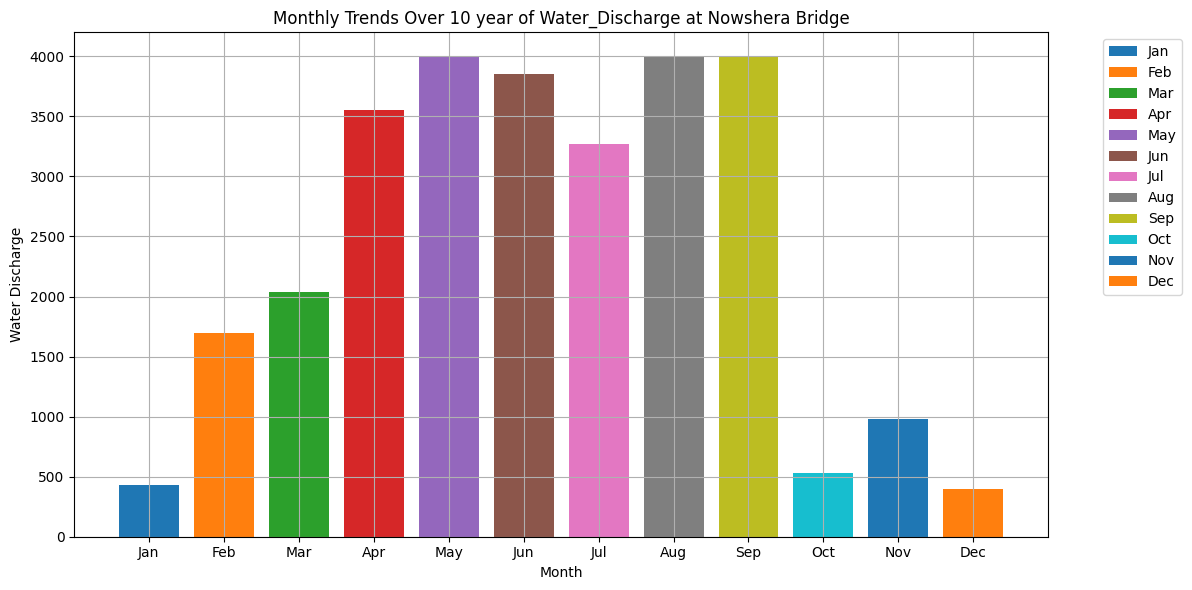

Plot saved to: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\monthly_water_discharge.png


In [80]:
import os
import calendar

# Save plot in the same folder as flood_data.xlsx
save_path = os.path.join(os.path.dirname(os.path.abspath('flood_data.xlsx')), 'monthly_water_discharge.png')

plt.figure(figsize=(12, 6))
for month in df['Month'].unique():
    monthly_data = df[df['Month'] == month]
    plt.bar(monthly_data['Month'], monthly_data['Water_Discharge'], label=calendar.month_abbr[int(month)])

plt.xticks(ticks=range(1,13), labels=calendar.month_abbr[1:13])
plt.xlabel('Month')
plt.ylabel('Water Discharge')
plt.title('Monthly Trends Over 10 year of Water_Discharge at Nowshera Bridge')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {save_path}")

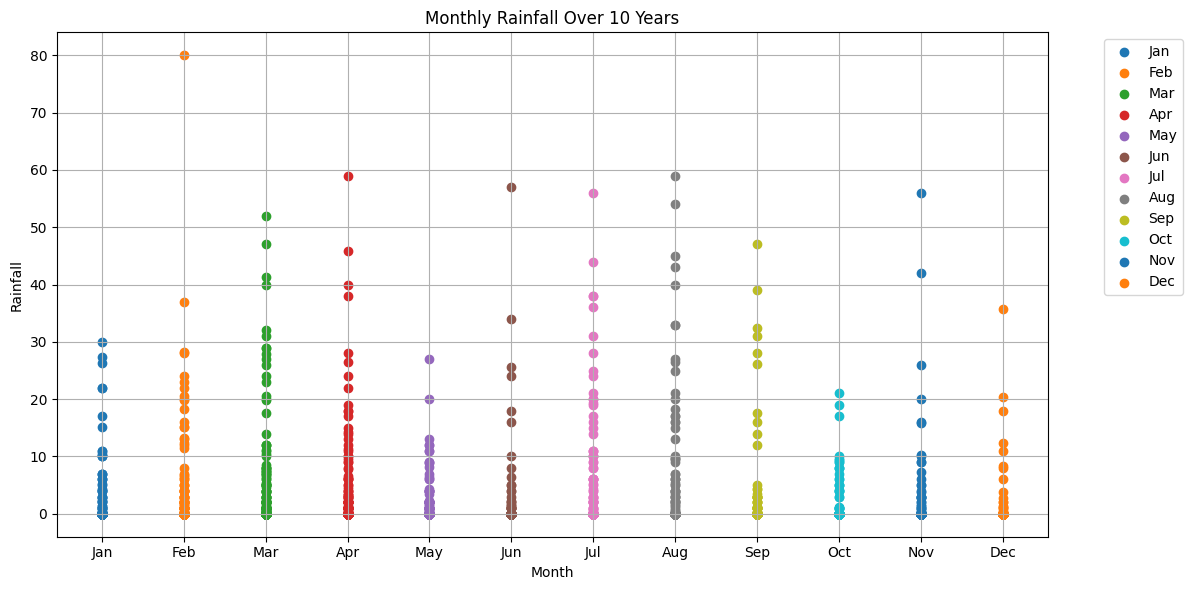

Plot saved to: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\monthly_rainfall.png


In [81]:
import matplotlib.pyplot as plt
import calendar
import os

# Save path same folder as flood_data.xlsx
save_path = os.path.join(os.path.dirname(os.path.abspath('flood_data.xlsx')), 'monthly_rainfall.png')

plt.figure(figsize=(12, 6))
for month in df['Month'].unique():
    monthly_data = df[df['Month'] == month]
    plt.scatter(monthly_data['Month'], monthly_data['Rainfall'], label=calendar.month_abbr[int(month)])

plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])
plt.xlabel('Month')
plt.ylabel('Rainfall')
plt.title('Monthly Rainfall Over 10 Years')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {save_path}")

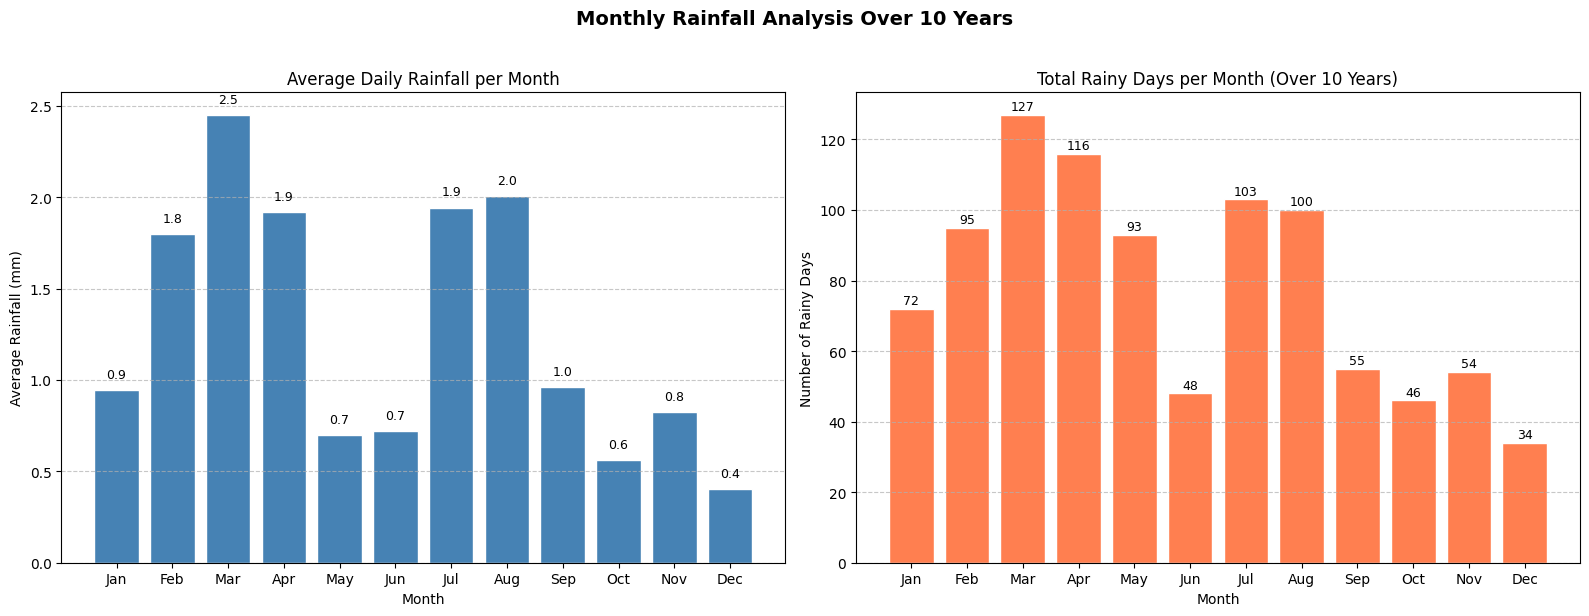

Plot saved to: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\monthly_rainfall_analysis.png


In [82]:
import matplotlib.pyplot as plt
import calendar
import os

# Save path same folder as flood_data.xlsx
save_path = os.path.join(os.path.dirname(os.path.abspath('flood_data.xlsx')), 'monthly_rainfall_analysis.png')

# Prepare data
monthly_avg = df.groupby('Month')['Rainfall'].mean()
monthly_rainy_days = df[df['Rainfall'] > 0].groupby('Month')['Rainfall'].count()

month_labels = calendar.month_abbr[1:13]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left chart: Average monthly rainfall ---
ax1.bar(range(1, 13), monthly_avg, color='steelblue', edgecolor='white')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Rainfall (mm)')
ax1.set_title('Average Daily Rainfall per Month')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, val in enumerate(monthly_avg):
    ax1.text(i + 1, val + 0.05, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# --- Right chart: Number of rainy days per month ---
ax2.bar(range(1, 13), monthly_rainy_days, color='coral', edgecolor='white')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Rainy Days')
ax2.set_title('Total Rainy Days per Month (Over 10 Years)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, val in enumerate(monthly_rainy_days):
    ax2.text(i + 1, val + 0.5, f'{int(val)}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Monthly Rainfall Analysis Over 10 Years', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {save_path}")

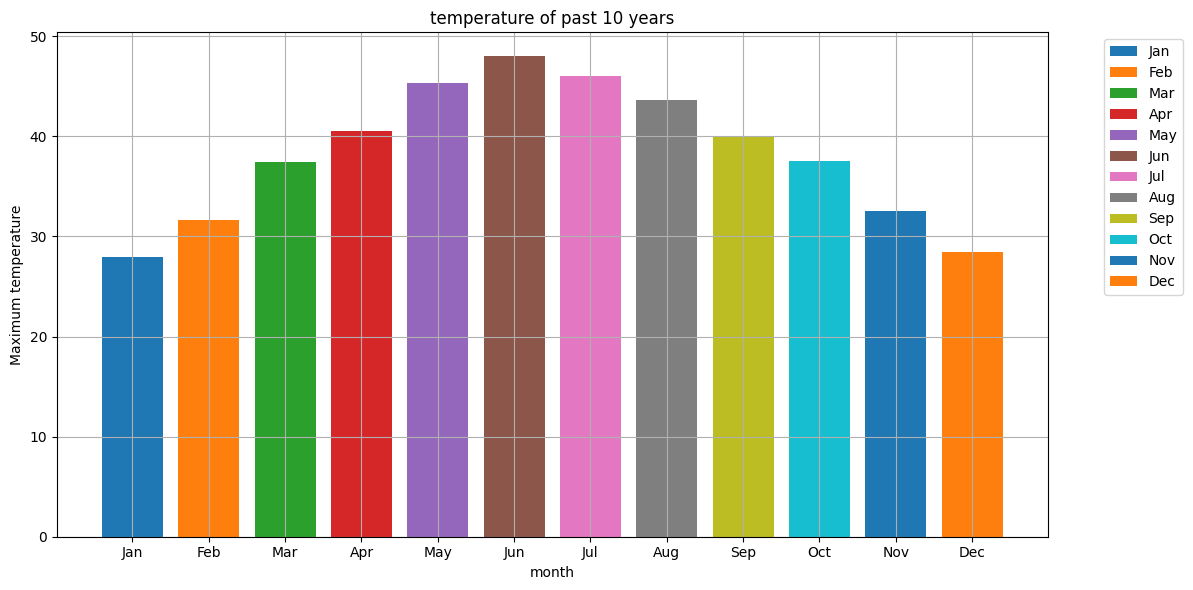

In [83]:
plt.figure(figsize=(12, 6))

for month in df['Month'].unique():

    monthly_data = df[df['Month'] == month]


    plt.bar(monthly_data['Month'], monthly_data['Maximum_Temperature'], label=calendar.month_abbr[int(month)])
plt.xticks(ticks=range(1,13),labels=calendar.month_abbr[1:13])
plt.xlabel('month')

plt.ylabel('Maximum temperature')
plt.title('temperature of past 10 years')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
#Cyclic Encoding of Time Features (Feature Engineering)
import numpy as np

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
df['Day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)
df.head()

,Year,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff,Month_sin,Month_cos,Day_sin,Day_cos
0,2012,1,1,22.0,5.0,0.00,11.35,185.5,17.0,0.5,0.866025,0.201299,0.979530
1,2012,1,2,20.5,5.0,0.00,10.65,235.1,15.5,0.5,0.866025,0.394356,0.918958
2,2012,1,3,20.8,5.0,0.00,10.90,235.0,15.8,0.5,0.866025,0.571268,0.820763
3,2012,1,4,15.0,5.0,0.00,8.35,247.4,10.0,0.5,0.866025,0.724793,0.688967
4,2012,1,5,15.0,5.4,0.05,10.20,267.9,9.6,0.5,0.866025,0.848644,0.528964


In [61]:
df=df.drop(['Month','Day'],axis=1)#no need of these column, Fearure Selection

x=df[['Maximum_Temperature','Minimum_Temperature','Average_Temperature','Rainfall','Month_sin','Month_cos','Day_sin','Day_cos','Temp_Diff']]
y=df['Water_Discharge']

In [85]:
#making sure Water_Discharge (y) is not in input (x). 
print("Features (X):")
x.head()

Features (X):


,Maximum_Temperature,Minimum_Temperature,Average_Temperature,Rainfall,Month_sin,Month_cos,Day_sin,Day_cos,Temp_Diff
0,22.0,5.0,11.35,0.00,0.5,0.866025,0.201299,0.979530,17.0
1,20.5,5.0,10.65,0.00,0.5,0.866025,0.394356,0.918958,15.5
2,20.8,5.0,10.90,0.00,0.5,0.866025,0.571268,0.820763,15.8
3,15.0,5.0,8.35,0.00,0.5,0.866025,0.724793,0.688967,10.0
4,15.0,5.4,10.20,0.05,0.5,0.866025,0.848644,0.528964,9.6


In [86]:
df.head()

,Year,Month,Day,Maximum_Temperature,Minimum_Temperature,Rainfall,Average_Temperature,Water_Discharge,Temp_Diff,Month_sin,Month_cos,Day_sin,Day_cos
0,2012,1,1,22.0,5.0,0.00,11.35,185.5,17.0,0.5,0.866025,0.201299,0.979530
1,2012,1,2,20.5,5.0,0.00,10.65,235.1,15.5,0.5,0.866025,0.394356,0.918958
2,2012,1,3,20.8,5.0,0.00,10.90,235.0,15.8,0.5,0.866025,0.571268,0.820763
3,2012,1,4,15.0,5.0,0.00,8.35,247.4,10.0,0.5,0.866025,0.724793,0.688967
4,2012,1,5,15.0,5.4,0.05,10.20,267.9,9.6,0.5,0.866025,0.848644,0.528964


In [87]:
print(df['Rainfall'].max()) #Just checking

80.0


In [89]:
#Saving automatically to Excel with all the model results
#====================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping


# ===================== CONFIG =====================
BASE_COLS = [
    'Maximum_Temperature', 'Minimum_Temperature', 'Average_Temperature',
    'Rainfall', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_Diff'
]

# Lag configurations: each tuple = (discharge_lags, rainfall_lags, total_lags)
# 4→(2,2), 6→(3,3), 10→(5,5), 20→(10,10), 30→(15,15), 40→(20,20), 50→(25,25)
LAG_CONFIGS = [
    (2,  2,  4),
    (3,  3,  6),
    (5,  5,  10),
    (10, 10, 20),
    (15, 15, 30),
    (20, 20, 40),
    (25, 25, 50),
]

KF = KFold(n_splits=5, shuffle=False)

# Save results in the same directory as the dataset
SAVE_DIR = os.path.dirname(os.path.abspath('flood_data.xlsx'))
RESULTS_EXCEL = os.path.join(SAVE_DIR, 'lag_experiment_results.xlsx')


# ===================== METRICS =====================
def get_metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mse, rmse, mae


# ===================== PLOT & SAVE =====================  
def plot_results(y_true, y_pred, model_name, lag_total, n=200):
    y_true_arr = np.array(y_true).flatten()
    y_pred_arr = np.array(y_pred).flatten()
    n = min(n, len(y_true_arr))

    plt.figure(figsize=(15, 5))
    plt.plot(y_true_arr[:n], label="Actual",    marker="o", markersize=3, linewidth=1)
    plt.plot(y_pred_arr[:n], label="Predicted", marker="o", markersize=3,
             linewidth=1, linestyle="--")
    r2, _, rmse, _ = get_metrics(y_true_arr, y_pred_arr)
    plt.title(f"{model_name} | Lag={lag_total} | First {n} Predictions\n"
              f"R²: {r2:.3f} | RMSE: {rmse:.2f} m³/s")
    plt.xlabel("Time Index")
    plt.ylabel("Water Discharge (m³/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    fname = os.path.join(SAVE_DIR,
        f"graph_{model_name.lower().replace(' ', '_')}_lag{lag_total}.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Graph saved: {fname}")


# ===================== LSTM SEQUENCE BUILDER =====================
def make_sequences(X_scaled, y_arr, window):
    Xs, ys = [], []
    for i in range(window, len(X_scaled)):
        Xs.append(X_scaled[i - window:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)


# ===================== MODEL RUNNERS =====================

def run_random_forest(X_train_norm, X_test_norm, y_train, y_test, lag_total):
    print(f"  [RF] lag={lag_total}")
    param_grid = {
        "n_estimators"     : [100, 160],
        "max_depth"        : [None, 10, 20],
        "min_samples_split": [2, 5]
    }
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid, cv=KF, scoring="r2", n_jobs=-1
    )
    grid.fit(X_train_norm, y_train)
    preds = grid.best_estimator_.predict(X_test_norm)
    plot_results(y_test, preds, "Random Forest", lag_total)
    return get_metrics(y_test, preds)


def run_xgboost(X_train_norm, X_test_norm, y_train, y_test, lag_total):
    print(f"  [XGB] lag={lag_total}")
    param_grid = {
        "n_estimators" : [100, 160],
        "learning_rate": [0.05, 0.1],
        "max_depth"    : [3, 5, 7],
        "subsample"    : [0.8, 1.0]
    }
    grid = GridSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
        param_grid, cv=KF, scoring="r2", n_jobs=-1
    )
    grid.fit(X_train_norm, y_train)
    preds = grid.best_estimator_.predict(X_test_norm)
    plot_results(y_test, preds, "XGBoost", lag_total)
    return get_metrics(y_test, preds)


def run_svm(X_train, X_test, y_train, y_test, lag_total):
    print(f"  [SVM] lag={lag_total}")
    param_grid = {
        "svm__C"      : [1, 10, 100],
        "svm__gamma"  : ["scale", 0.1, 0.01],
        "svm__epsilon": [0.1, 0.2]
    }
    pipeline = Pipeline([("scaler", MinMaxScaler()), ("svm", SVR(kernel="rbf"))])
    grid = GridSearchCV(pipeline, param_grid, cv=KF, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)
    plot_results(y_test, preds, "SVM", lag_total)
    return get_metrics(y_test, preds)


def run_ridge(X_train, X_test, y_train, y_test, lag_total):
    print(f"  [Ridge] lag={lag_total}")
    param_grid = {"ridge__alpha": [0.01, 0.1, 1, 10, 100]}
    pipeline = Pipeline([("scaler", MinMaxScaler()), ("ridge", Ridge())])
    grid = GridSearchCV(pipeline, param_grid, cv=KF, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)
    plot_results(y_test, preds, "Ridge Regression", lag_total)
    return get_metrics(y_test, preds)


def run_ann(X_train, X_test, y_train, y_test, lag_total):
    print(f"  [ANN] lag={lag_total}")
    ann_scaler = MinMaxScaler()
    X_tr = ann_scaler.fit_transform(X_train)
    X_te = ann_scaler.transform(X_test)
    y_tr = np.array(y_train)
    y_te = np.array(y_test)

    def build_ann(n_features):
        m = Sequential([
            Dense(128, activation='relu', input_shape=(n_features,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        m.compile(optimizer='adam', loss='mse')
        return m

    # K-Fold CV — same as original
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(KF.split(X_tr)):
        model = build_ann(X_tr.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_tr[train_idx], y_tr[train_idx],
                  validation_data=(X_tr[val_idx], y_tr[val_idx]),
                  epochs=100, batch_size=32, callbacks=[es], verbose=0)
        val_pred = model.predict(X_tr[val_idx], verbose=0).flatten()
        fold_r2  = r2_score(y_tr[val_idx], val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"  Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # Final model on full training data
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final = build_ann(X_tr.shape[1])
    final.fit(X_tr, y_tr, validation_split=0.1,
              epochs=200, batch_size=32, callbacks=[es], verbose=0)

    preds = final.predict(X_te, verbose=0).flatten()
    plot_results(y_te, preds, "ANN", lag_total)
    return get_metrics(y_te, preds)


def run_lstm(X_train, X_test, y_train, y_test, lag_cols_used, lag_total):
    print(f"  [LSTM] lag={lag_total}")
    WINDOW = max(lag_total // 2, 5)

    X_seq_tr     = X_train[BASE_COLS].values
    X_seq_te     = X_test[BASE_COLS].values
    X_aux_tr     = X_train[BASE_COLS + lag_cols_used].values
    X_aux_te     = X_test[BASE_COLS + lag_cols_used].values

    y_tr = np.array(y_train).reshape(-1, 1)
    y_te = np.array(y_test).flatten()

    seq_scaler = MinMaxScaler()
    aux_scaler = MinMaxScaler()
    y_scaler   = MinMaxScaler()

    X_seq_tr_s = seq_scaler.fit_transform(X_seq_tr)
    X_seq_te_s = seq_scaler.transform(X_seq_te)
    X_aux_tr_s = aux_scaler.fit_transform(X_aux_tr)
    X_aux_te_s = aux_scaler.transform(X_aux_te)
    y_tr_s     = y_scaler.fit_transform(y_tr).flatten()

    X_seq_3d_tr, y_seq_tr = make_sequences(X_seq_tr_s, y_tr_s, WINDOW)
    X_seq_3d_te, y_seq_te = make_sequences(X_seq_te_s, y_te,   WINDOW)
    X_aux_2d_tr = X_aux_tr_s[WINDOW:]
    X_aux_2d_te = X_aux_te_s[WINDOW:]

    n_aux = X_aux_2d_tr.shape[1]

    def build_lstm():
        seq_in = Input(shape=(WINDOW, 9), name='seq')
        x = LSTM(64, return_sequences=True)(seq_in)
        x = Dropout(0.2)(x)
        x = LSTM(32)(x)
        x = Dropout(0.2)(x)

        aux_in = Input(shape=(n_aux,), name='aux')
        a = Dense(32, activation='relu')(aux_in)

        merged = Concatenate()([x, a])
        merged = Dense(32, activation='relu')(merged)
        out    = Dense(1)(merged)
        m = Model(inputs=[seq_in, aux_in], outputs=out)
        m.compile(optimizer='adam', loss='mse')
        return m

    # ── K-Fold CV ──────────────────────────────────────────────
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(KF.split(X_seq_3d_tr)):
        model = build_lstm()
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(
            [X_seq_3d_tr[train_idx], X_aux_2d_tr[train_idx]],
            y_seq_tr[train_idx],
            validation_data=(
                [X_seq_3d_tr[val_idx], X_aux_2d_tr[val_idx]],
                y_seq_tr[val_idx]
            ),
            epochs=100, batch_size=32, callbacks=[es], verbose=0
        )
        val_pred = y_scaler.inverse_transform(
            model.predict(
                [X_seq_3d_tr[val_idx], X_aux_2d_tr[val_idx]], verbose=0
            ).reshape(-1, 1)
        ).flatten()
        val_true = y_scaler.inverse_transform(
            y_seq_tr[val_idx].reshape(-1, 1)
        ).flatten()
        fold_r2 = r2_score(val_true, val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"  Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # ── Final model on full training data ──────────────────────
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final = build_lstm()
    final.fit(
        [X_seq_3d_tr, X_aux_2d_tr], y_seq_tr,
        validation_split=0.1, epochs=200, batch_size=32,
        callbacks=[es], verbose=0
    )

    pred_s = final.predict([X_seq_3d_te, X_aux_2d_te], verbose=0).flatten()
    preds  = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    plot_results(y_seq_te, preds, "LSTM", lag_total)
    return get_metrics(y_seq_te, preds)


# ===================== EXCEL WRITER =====================
def save_results_to_excel(all_results):
    """
    all_results: list of dicts, one per (lag_config, model)
    Keys: lag_total, discharge_lags, rainfall_lags,
          total_features, model, R2, MSE, RMSE, MAE
    """
    wb = Workbook()
    ws = wb.active
    ws.title = "Lag Experiment Results"

    # --- Styles ---
    BLUE   = "1F4E79"
    LBLUE  = "BDD7EE"
    GREEN  = "375623"
    LGREEN = "E2EFDA"
    GREY   = "F2F2F2"
    WHITE  = "FFFFFF"
    ORANGE = "F4B942"

    def hdr_style(cell, bg, fg="FFFFFF", bold=True, center=True):
        cell.font      = Font(bold=bold, color=fg, name="Arial", size=11)
        cell.fill      = PatternFill("solid", start_color=bg)
        cell.alignment = Alignment(horizontal="center" if center else "left",
                                   vertical="center", wrap_text=True)

    def data_style(cell, bg=WHITE, bold=False, center=True):
        cell.font      = Font(bold=bold, color="000000", name="Arial", size=10)
        cell.fill      = PatternFill("solid", start_color=bg)
        cell.alignment = Alignment(horizontal="center" if center else "left",
                                   vertical="center")

    thin = Side(style="thin", color="BFBFBF")
    def border(cell):
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # --- Title ---
    ws.merge_cells("A1:J1")
    ws["A1"] = "Water Discharge Prediction — Lag Feature Experiment Results"
    ws["A1"].font      = Font(bold=True, color=WHITE, name="Arial", size=14)
    ws["A1"].fill      = PatternFill("solid", start_color=BLUE)
    ws["A1"].alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    ws.merge_cells("A2:J2")
    ws["A2"] = ("Base features (9): Maximum_Temperature, Minimum_Temperature, "
                "Average_Temperature, Rainfall, Month_sin, Month_cos, Day_sin, Day_cos, Temp_Diff")
    ws["A2"].font      = Font(italic=True, color="000000", name="Arial", size=10)
    ws["A2"].fill      = PatternFill("solid", start_color=LBLUE)
    ws["A2"].alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.row_dimensions[2].height = 20

    # Column headers
    COLS = ["Lag Config", "Discharge Lags", "Rainfall Lags",
            "Total Lag Features", "Base Features", "Total Features",
            "Model", "R²", "MSE", "RMSE (m³/s)", "MAE (m³/s)"]
    ws.column_dimensions["A"].width = 14
    ws.column_dimensions["B"].width = 16
    ws.column_dimensions["C"].width = 16
    ws.column_dimensions["D"].width = 18
    ws.column_dimensions["E"].width = 14
    ws.column_dimensions["F"].width = 14
    ws.column_dimensions["G"].width = 20
    ws.column_dimensions["H"].width = 10
    ws.column_dimensions["I"].width = 14
    ws.column_dimensions["J"].width = 16
    ws.column_dimensions["K"].width = 14

    hdr_row = 3
    for col_idx, col_name in enumerate(COLS, start=1):
        cell = ws.cell(row=hdr_row, column=col_idx, value=col_name)
        hdr_style(cell, GREEN)
        border(cell)
    ws.row_dimensions[hdr_row].height = 22

    # --- Data rows grouped by lag config ---
    models = ["Random Forest", "XGBoost", "SVM", "Ridge Regression", "ANN", "LSTM"]
    current_row = hdr_row + 1

    for lag_d, lag_r, lag_total in LAG_CONFIGS:
        block_start = current_row
        block_data  = [r for r in all_results
                       if r["lag_total"] == lag_total]

        for i, model_name in enumerate(models):
            row_data = next((r for r in block_data if r["model"] == model_name), None)
            bg = LGREEN if i % 2 == 0 else GREY

            cells = [
                lag_total,
                lag_d,
                lag_r,
                lag_total,
                9,
                9 + lag_total,
                model_name,
                round(row_data["R2"],   4) if row_data else "N/A",
                round(row_data["MSE"],  4) if row_data else "N/A",
                round(row_data["RMSE"], 4) if row_data else "N/A",
                round(row_data["MAE"],  4) if row_data else "N/A",
            ]
            for col_idx, val in enumerate(cells, start=1):
                cell = ws.cell(row=current_row, column=col_idx, value=val)
                data_style(cell, bg)
                border(cell)
            current_row += 1

        # Merge lag config label across the block rows
        if block_start < current_row - 1:
            ws.merge_cells(
                start_row=block_start, start_column=1,
                end_row=current_row - 1, end_column=1
            )
        label_cell = ws.cell(row=block_start, column=1,
                             value=f"Lag {lag_total}\n({lag_d}D + {lag_r}R)")
        hdr_style(label_cell, ORANGE, fg="000000")
        border(label_cell)

        # Empty separator row between blocks
        ws.row_dimensions[current_row].height = 8
        current_row += 1

    # Freeze panes
    ws.freeze_panes = "A4"

    wb.save(RESULTS_EXCEL)
    print(f"\nResults saved to: {RESULTS_EXCEL}")


# ===================== MAIN LOOP =====================
all_results = []

# Load preprocessed clean df for each lag config (lag feature engineering modifies df)
df_original = df.copy()

for lag_d, lag_r, lag_total in LAG_CONFIGS:
    print(f"\n{'='*60}")
    print(f"LAG CONFIG: {lag_d} Discharge lags + {lag_r} Rainfall lags = {lag_total} total")
    print(f"{'='*60}")

    # Work on a fresh copy each iteration
    df_iter = df_original.copy()

    # Add lag features for this config
    for lag in range(1, lag_d + 1):
        df_iter[f'Discharge_lag_{lag}'] = df_iter['Water_Discharge'].shift(lag)
    for lag in range(1, lag_r + 1):
        df_iter[f'Rainfall_lag_{lag}']  = df_iter['Rainfall'].shift(lag)

    df_iter = df_iter.dropna().reset_index(drop=True)

    lag_cols_used = ([f'Discharge_lag_{i}' for i in range(1, lag_d + 1)] +
                     [f'Rainfall_lag_{i}'  for i in range(1, lag_r + 1)])

    x = df_iter[BASE_COLS + lag_cols_used]
    y = df_iter['Water_Discharge']

    print(f"Feature matrix: {x.shape[1]} features "
          f"(9 base + {lag_total} lag) | Rows: {len(x)}")

    # Chronological split 80/20
    split = int(len(x) * 0.8)
    X_train, X_test = x.iloc[:split], x.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Normalise (for RF, XGBoost, ANN — SVM & Ridge use Pipeline internally)
    scaler      = MinMaxScaler()
    X_train_n   = scaler.fit_transform(X_train)
    X_test_n    = scaler.transform(X_test)

    # Run all models
    for model_name, runner_fn, args in [
        ("Random Forest",    run_random_forest, (X_train_n, X_test_n, y_train, y_test, lag_total)),
        ("XGBoost",          run_xgboost,       (X_train_n, X_test_n, y_train, y_test, lag_total)),
        ("SVM",              run_svm,            (X_train, X_test, y_train, y_test, lag_total)),
        ("Ridge Regression", run_ridge,          (X_train, X_test, y_train, y_test, lag_total)),
        ("ANN",              run_ann,            (X_train, X_test, y_train, y_test, lag_total)),
        ("LSTM",             run_lstm,           (X_train, X_test, y_train, y_test, lag_cols_used, lag_total)),
    ]:
        r2, mse, rmse, mae = runner_fn(*args)
        print(f"    {model_name}: R²={r2:.4f} | RMSE={rmse:.2f}")
        all_results.append({
            "lag_total"      : lag_total,
            "discharge_lags" : lag_d,
            "rainfall_lags"  : lag_r,
            "model"          : model_name,
            "R2"             : r2,
            "MSE"            : mse,
            "RMSE"           : rmse,
            "MAE"            : mae,
        })

# Save everything to Excel
save_results_to_excel(all_results)
print("\nAll done.")


LAG CONFIG: 2 Discharge lags + 2 Rainfall lags = 4 total
Feature matrix: 13 features (9 base + 4 lag) | Rows: 4016
  [RF] lag=4


KeyboardInterrupt: 

Feature matrix shape : (3997, 49)
Total features       : 49  (9 base + 40 lag)
Train size: 3197 | Test size: 800
Test period:
3217
3996

--- LSTM (Fixed: sequence on base features, lags as current-step context) ---
Sequence input shape : (3177, 20, 9)
Aux input shape      : (3177, 49)
  Fold 1 R²: 0.9121
  Fold 2 R²: 0.9677
  Fold 3 R²: 0.9379
  Fold 4 R²: 0.9621
  Fold 5 R²: 0.9272
Average CV R²: 0.9414 ± 0.0209
Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0063 - val_loss: 0.0064
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0036 - val_loss: 0.0065
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0030 - val_loss: 0.0050
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0025 - val_loss: 0.0048
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0022 - val_loss: 0.0045
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0021 - val_loss: 0.0044
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0020

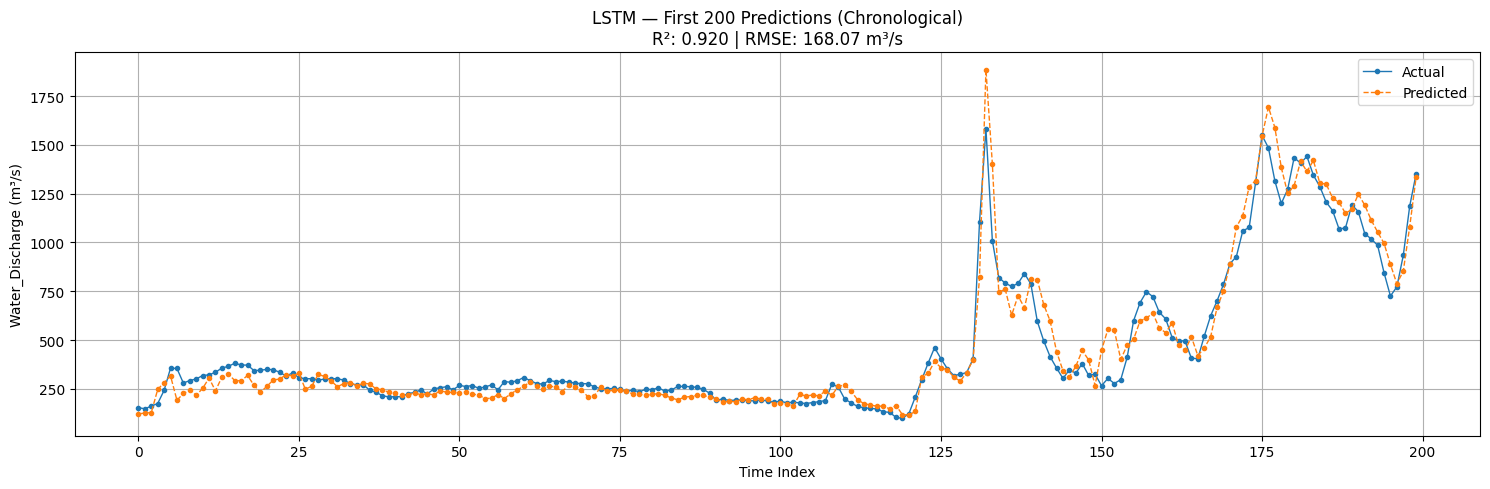

Graph saved: graph_lstm_with_gridsearch_cv.png


In [19]:
# All Six Models: Random Forest, XGBoost, SVM, Ridge Regression, ANN, LSTM
# K-Fold Temporal CV + GridSearchCV + Lag Features for fair comparison

# ===================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras.callbacks import EarlyStopping


# ===================== STEP 1: FEATURE ENGINEERING =====================
# Add lag features (20 days) — gives ML models same historical context as ANN/LSTM
for lag in range(1, 21):
    df[f'Discharge_lag_{lag}'] = df['Water_Discharge'].shift(lag)
    df[f'Rainfall_lag_{lag}']  = df['Rainfall'].shift(lag)

# Drop first 20 rows where lag values are NaN
df = df.dropna().reset_index(drop=True)


# ===================== STEP 2: FEATURE MATRIX =====================
lag_cols  = [f'Discharge_lag_{i}' for i in range(1, 21)] + \
            [f'Rainfall_lag_{i}'  for i in range(1, 21)]

base_cols = ['Maximum_Temperature', 'Minimum_Temperature', 'Average_Temperature',
             'Rainfall', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_Diff']

x = df[base_cols + lag_cols]
y = df['Water_Discharge']

print(f"Feature matrix shape : {x.shape}")
print(f"Total features       : {x.shape[1]}  (9 base + 40 lag)")


# ===================== STEP 3: CHRONOLOGICAL SPLIT =====================
split_index = int(len(x) * 0.8)

X_train = x.iloc[:split_index]
X_test  = x.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

print("Test period:")
print(df.index[split_index + 20])
print(df.index[-1])

# ===================== STEP 4: NORMALIZATION =====================
# Used for RF and XGBoost directly
# SVM and Ridge handle scaling internally via Pipeline
# ANN and LSTM use their own scaler defined inside their functions
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm  = scaler.transform(X_test)


# ===================== STEP 5: K-FOLD (NO SHUFFLE) =====================
kf = KFold(n_splits=5, shuffle=False)


# ===================== STEP 6: METRICS FUNCTION =====================
def print_metrics(y_true, y_pred, model_name="Model"):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {model_name} — Test Metrics")
    print(f"{'='*45}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/s")
    print(f"  MAE  : {mae:.4f} m³/s")
    print(f"{'='*45}")

    return r2, mse, rmse, mae


# ===================== STEP 7: PLOT & SAVE FUNCTION =====================
def plot_results(y_true, y_pred, model_name, n=200):
    y_true_arr = np.array(y_true).flatten()
    y_pred_arr = np.array(y_pred).flatten()
    n = min(n, len(y_true_arr))

    y_true_subset = y_true_arr[:n]
    y_pred_subset = y_pred_arr[:n]

    # --- Save Excel ---
    results_table = pd.DataFrame({
        "Index"               : range(n),
        "Actual_Discharge"    : y_true_subset,
        "Predicted_Discharge" : y_pred_subset,
        "Error"               : y_true_subset - y_pred_subset
    })

    filename_excel = f"{model_name.lower().replace(' ', '_')}_with_gridsearch_cv_predictions.xlsx"
    results_table.to_excel(filename_excel, index=False)
    print(f"Table saved: {filename_excel}")

    # --- Save Plot ---
    plt.figure(figsize=(15, 5))
    plt.plot(y_true_subset, label="Actual",    marker="o", markersize=3, linewidth=1)
    plt.plot(y_pred_subset, label="Predicted", marker="o", markersize=3,
             linewidth=1, linestyle="--")
    plt.title(f"{model_name} — First {n} Predictions (Chronological)\n"
              f"R²: {r2_score(y_true_arr, y_pred_arr):.3f} | "
              f"RMSE: {np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)):.2f} m³/s")
    plt.xlabel("Time Index")
    plt.ylabel("Water_Discharge (m³/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename_graph = f"graph_{model_name.lower().replace(' ', '_')}_with_gridsearch_cv.png"
    plt.savefig(filename_graph, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Graph saved: {filename_graph}")


# ===================== STEP 8: LSTM HELPER — SEQUENCE BUILDER =====================
# Builds sliding window sequences for LSTM from base features only
# Each sample = 20 consecutive days of 9 base features → LSTM learns temporal pattern
# window=20 matches the lag window used by all other models for fair comparison

def make_sequences(X_scaled, y_arr, window=20):
    Xs, ys = [], []
    for i in range(window, len(X_scaled)):
        Xs.append(X_scaled[i - window:i])   # shape: (window, n_features)
        ys.append(y_arr[i])                  # target: next day discharge
    return np.array(Xs), np.array(ys)


# ===================== STEP 9: MODEL RUNNERS =====================

# ---- Random Forest: scale-invariant, no Pipeline needed ----
def run_random_forest():
    print("\n--- Random Forest (GridSearch + 5-Fold Temporal CV) ---")

    param_grid = {
        "n_estimators"     : [100, 160],
        "max_depth"        : [None, 10, 20],
        "min_samples_split": [2, 5]
    }

    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train_norm, y_train)

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    predictions = grid.best_estimator_.predict(X_test_norm)
    print_metrics(y_test, predictions, "Random Forest")
    plot_results(y_test, predictions, "Random Forest")


# ---- XGBoost: scale-invariant, no Pipeline needed ----
def run_xgboost():
    print("\n--- XGBoost (GridSearch + 5-Fold Temporal CV) ---")

    param_grid = {
        "n_estimators" : [100, 160],
        "learning_rate": [0.05, 0.1],
        "max_depth"    : [3, 5, 7],
        "subsample"    : [0.8, 1.0]
    }

    grid = GridSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train_norm, y_train)

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    predictions = grid.best_estimator_.predict(X_test_norm)
    print_metrics(y_test, predictions, "XGBoost")
    plot_results(y_test, predictions, "XGBoost")


# ---- SVM: scale-sensitive, Pipeline wraps GridSearchCV (NO leakage) ----
def run_svm():
    print("\n--- SVM (GridSearch + 5-Fold Temporal CV + Pipeline) ---")

    param_grid = {
        "svm__C"      : [1, 10, 100],
        "svm__gamma"  : ["scale", 0.1, 0.01],
        "svm__epsilon": [0.1, 0.2]
    }

    pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("svm",    SVR(kernel="rbf"))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    # Pass RAW X_train — Pipeline fits scaler on train fold only, each iteration
    grid.fit(X_train, y_train)

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    # Pipeline scales X_test internally during predict
    predictions = grid.best_estimator_.predict(X_test)
    print_metrics(y_test, predictions, "SVM")
    plot_results(y_test, predictions, "SVM")


# ---- Ridge: scale-sensitive, Pipeline wraps GridSearchCV (NO leakage) ----
def run_ridge():
    print("\n--- Ridge Regression (GridSearch + 5-Fold Temporal CV + Pipeline) ---")

    param_grid = {
        "ridge__alpha": [0.01, 0.1, 1, 10, 100]
    }

    pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("ridge",  Ridge())
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    # Pass RAW X_train — Pipeline fits scaler per fold internally
    grid.fit(X_train, y_train)

    best_pipeline = grid.best_estimator_

    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R²  : {grid.best_score_:.4f}")

    predictions = best_pipeline.predict(X_test)
    print_metrics(y_test, predictions, "Ridge Regression")
    plot_results(y_test, predictions, "Ridge Regression")

    # Save pipeline (includes scaler + model — no separate scaler needed)
    with open("ridge_pipeline_with_gridsearch_cv.pkl", "wb") as f:
        pickle.dump(best_pipeline, f)
    print("Ridge pipeline saved as ridge_pipeline_with_gridsearch_cv.pkl")


# ---- ANN: scale-sensitive, own scaler, no GridSearch (Keras not compatible) ----
def run_ann():
    print("\n--- ANN (5-Fold Temporal CV — EarlyStopping) ---")

    # ANN uses its own scaler fitted on X_train only
    ann_scaler = MinMaxScaler()
    X_train_ann = ann_scaler.fit_transform(X_train)
    X_test_ann  = ann_scaler.transform(X_test)

    y_train_arr = np.array(y_train)
    y_test_arr  = np.array(y_test)

    # K-Fold CV to report training stability
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_ann)):
        X_fold_train, X_fold_val = X_train_ann[train_idx], X_train_ann[val_idx]
        y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

        model = Sequential([
            Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')

        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_fold_train, y_fold_train,
                  validation_data=(X_fold_val, y_fold_val),
                  epochs=100, batch_size=32,
                  callbacks=[es], verbose=0)

        val_pred  = model.predict(X_fold_val, verbose=0).flatten()
        fold_r2   = r2_score(y_fold_val, val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # Final model trained on full training data
    final_model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    final_model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final_model.fit(X_train_ann, y_train_arr,
                    validation_split=0.1,
                    epochs=200, batch_size=32,
                    callbacks=[es], verbose=1)

    predictions = final_model.predict(X_test_ann, verbose=0).flatten()
    print_metrics(y_test_arr, predictions, "ANN")
    plot_results(y_test_arr, predictions, "ANN")

def run_lstm():
    print("\n--- LSTM (Fixed: sequence on base features, lags as current-step context) ---")

    WINDOW = 20

    base_cols = [
        'Maximum_Temperature', 'Minimum_Temperature', 'Average_Temperature',
        'Rainfall', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_Diff'
    ]
    lag_cols = [f'Discharge_lag_{i}' for i in range(1, 21)] + \
               [f'Rainfall_lag_{i}'  for i in range(1, 21)]

    # Sequence input: only base features over 20 timesteps — LSTM learns temporal pattern
    X_seq_part  = X_train[base_cols].values   # (n_train, 9)
    X_seq_test_part = X_test[base_cols].values

    # Auxiliary input: all 49 features at current timestep only — gives LSTM the lag context
    X_aux_part  = X_train[base_cols + lag_cols].values   # (n_train, 49)
    X_aux_test_part = X_test[base_cols + lag_cols].values

    y_train_arr = np.array(y_train).reshape(-1, 1)
    y_test_arr  = np.array(y_test).flatten()

    # Scale both inputs — fit on train only
    seq_scaler = MinMaxScaler()
    aux_scaler = MinMaxScaler()
    lstm_y_scaler = MinMaxScaler()

    X_seq_scaled      = seq_scaler.fit_transform(X_seq_part)
    X_seq_test_scaled = seq_scaler.transform(X_seq_test_part)

    X_aux_scaled      = aux_scaler.fit_transform(X_aux_part)
    X_aux_test_scaled = aux_scaler.transform(X_aux_test_part)

    y_train_scaled = lstm_y_scaler.fit_transform(y_train_arr).flatten()

    # Build sequences for the base-feature window
    X_seq_train_3d, y_seq_train = make_sequences(X_seq_scaled,      y_train_scaled, window=WINDOW)
    X_seq_test_3d,  y_seq_test  = make_sequences(X_seq_test_scaled,  y_test_arr,     window=WINDOW)

    # Aux input: take the row at position i (current timestep) for each sequence
    # make_sequences uses range(window, len(X)), so aux aligns at those same indices
    X_aux_train_2d = X_aux_scaled[WINDOW:]        # shape: (n_train-20, 49)
    X_aux_test_2d  = X_aux_test_scaled[WINDOW:]   # shape: (n_test-20,  49)

    print(f"Sequence input shape : {X_seq_train_3d.shape}")  # (n-20, 20, 9)
    print(f"Aux input shape      : {X_aux_train_2d.shape}")  # (n-20, 49)

    from tensorflow.keras.layers import Input, Concatenate, Flatten
    from tensorflow.keras.models import Model

    def build_model():
        # Branch 1: LSTM on 20-step window of 9 base features
        seq_input = Input(shape=(WINDOW, 9), name='seq_input')
        x = LSTM(64, return_sequences=True)(seq_input)
        x = Dropout(0.2)(x)
        x = LSTM(32, return_sequences=False)(x)
        x = Dropout(0.2)(x)

        # Branch 2: direct dense on 49 current-step features (incl. lags)
        aux_input = Input(shape=(49,), name='aux_input')
        a = Dense(32, activation='relu')(aux_input)

        # Merge both branches
        merged = Concatenate()([x, a])
        merged = Dense(32, activation='relu')(merged)
        output = Dense(1)(merged)

        model = Model(inputs=[seq_input, aux_input], outputs=output)
        model.compile(optimizer='adam', loss='mse')
        return model

    # K-Fold CV
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_seq_train_3d)):
        model = build_model()
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(
            [X_seq_train_3d[train_idx], X_aux_train_2d[train_idx]],
            y_seq_train[train_idx],
            validation_data=(
                [X_seq_train_3d[val_idx], X_aux_train_2d[val_idx]],
                y_seq_train[val_idx]
            ),
            epochs=100, batch_size=32, callbacks=[es], verbose=0
        )
        val_pred = lstm_y_scaler.inverse_transform(
            model.predict([X_seq_train_3d[val_idx], X_aux_train_2d[val_idx]], verbose=0).reshape(-1,1)
        ).flatten()
        val_true = lstm_y_scaler.inverse_transform(
            y_seq_train[val_idx].reshape(-1,1)
        ).flatten()
        fold_r2 = r2_score(val_true, val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # Final model
    final_model = build_model()
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final_model.fit(
        [X_seq_train_3d, X_aux_train_2d], y_seq_train,
        validation_split=0.1,
        epochs=200, batch_size=32, callbacks=[es], verbose=1
    )

    pred_scaled = final_model.predict(
        [X_seq_test_3d, X_aux_test_2d], verbose=0
    ).flatten()
    predictions = lstm_y_scaler.inverse_transform(
        pred_scaled.reshape(-1,1)
    ).flatten()

    print_metrics(y_seq_test, predictions, "LSTM")
    plot_results(y_seq_test, predictions, "LSTM")
# ===================== STEP 10: RUN ALL =====================
run_random_forest()
run_xgboost()
run_svm()
run_ridge()
run_ann()
run_lstm()

In [95]:
#Saving automatically to Excel with all the model results, using max_temp rather than rainfall as lag feature
#====================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

# ===================== REPRODUCIBILITY =====================
import random
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ===================== CONFIG =====================
BASE_COLS = [
    'Maximum_Temperature', 'Minimum_Temperature', 'Average_Temperature',
    'Rainfall', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_Diff'
]

# Lag configurations: each tuple = (discharge_lags, max_temp_lags, total_lags)
# 4→(2,2), 6→(3,3), 10→(5,5), 20→(10,10), 30→(15,15), 40→(20,20), 50→(25,25)
LAG_CONFIGS = [
    # (2,  2,  4),
    # (3,  3,  6),
    # (5,  5,  10),
    (10, 10, 20),
    # (15, 15, 30),
    # (20, 20, 40),
    # (25, 25, 50),
]

KF = KFold(n_splits=5, shuffle=False)

# Save results in the same directory as the dataset
SAVE_DIR = os.path.dirname(os.path.abspath('flood_data.xlsx'))
RESULTS_EXCEL = os.path.join(SAVE_DIR, 'results/lag_experiment_results_ann_lstm_20_lag_max_temp_Water_discharge_2nd_try.xlsx')


# ===================== METRICS =====================
def get_metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, mse, rmse, mae


# ===================== PLOT & SAVE =====================  
def plot_results(y_true, y_pred, model_name, lag_total, n=200):
    y_true_arr = np.array(y_true).flatten()
    y_pred_arr = np.array(y_pred).flatten()
    n = min(n, len(y_true_arr))

    plt.figure(figsize=(15, 5))
    plt.plot(y_true_arr[:n], label="Actual",    marker="o", markersize=3, linewidth=1)
    plt.plot(y_pred_arr[:n], label="Predicted", marker="o", markersize=3,
             linewidth=1, linestyle="--")
    r2, _, rmse, _ = get_metrics(y_true_arr, y_pred_arr)
    plt.title(f"{model_name} | Lag={lag_total} | First {n} Predictions\n"
              f"R²: {r2:.3f} | RMSE: {rmse:.2f} m³/s")
    plt.xlabel("Time Index")
    plt.ylabel("Water Discharge (m³/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    fname = os.path.join(SAVE_DIR,
        f"graph_{model_name.lower().replace(' ', '_')}_lag{lag_total}.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Graph saved: {fname}")


# ===================== LSTM SEQUENCE BUILDER =====================
def make_sequences(X_scaled, y_arr, window):
    Xs, ys = [], []
    for i in range(window, len(X_scaled)):
        Xs.append(X_scaled[i - window:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)


# ===================== MODEL RUNNERS =====================

def run_random_forest(X_train_norm, X_test_norm, y_train, y_test, lag_total):
    print(f"  [RF] lag={lag_total}")
    param_grid = {
        "n_estimators"     : [100, 160],
        "max_depth"        : [None, 10, 20],
        "min_samples_split": [2, 5]
    }
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid, cv=KF, scoring="r2", n_jobs=-1
    )
    grid.fit(X_train_norm, y_train)
    preds = grid.best_estimator_.predict(X_test_norm)
    plot_results(y_test, preds, "Random Forest", lag_total)
    return get_metrics(y_test, preds)


def run_xgboost(X_train_norm, X_test_norm, y_train, y_test, lag_total):
    print(f"  [XGB] lag={lag_total}")
    param_grid = {
        "n_estimators" : [100, 160],
        "learning_rate": [0.05, 0.1],
        "max_depth"    : [3, 5, 7],
        "subsample"    : [0.8, 1.0]
    }
    grid = GridSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
        param_grid, cv=KF, scoring="r2", n_jobs=-1
    )
    grid.fit(X_train_norm, y_train)
    preds = grid.best_estimator_.predict(X_test_norm)
    plot_results(y_test, preds, "XGBoost", lag_total)
    return get_metrics(y_test, preds)


def run_svm(X_train, X_test, y_train, y_test, lag_total):
    print(f"  [SVM] lag={lag_total}")
    param_grid = {
        "svm__C"      : [1, 10, 100],
        "svm__gamma"  : ["scale", 0.1, 0.01],
        "svm__epsilon": [0.1, 0.2]
    }
    pipeline = Pipeline([("scaler", MinMaxScaler()), ("svm", SVR(kernel="rbf"))])
    grid = GridSearchCV(pipeline, param_grid, cv=KF, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)
    plot_results(y_test, preds, "SVM", lag_total)
    return get_metrics(y_test, preds)


def run_ridge(X_train, X_test, y_train, y_test, lag_total):
    print(f"  [Ridge] lag={lag_total}")
    param_grid = {"ridge__alpha": [0.01, 0.1, 1, 10, 100]}
    pipeline = Pipeline([("scaler", MinMaxScaler()), ("ridge", Ridge())])
    grid = GridSearchCV(pipeline, param_grid, cv=KF, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    preds = grid.best_estimator_.predict(X_test)
    plot_results(y_test, preds, "Ridge Regression", lag_total)
    return get_metrics(y_test, preds)


def run_ann(X_train, X_test, y_train, y_test, lag_total):
    print(f"  [ANN] lag={lag_total}")
    ann_scaler = MinMaxScaler()
    X_tr = ann_scaler.fit_transform(X_train)
    X_te = ann_scaler.transform(X_test)
    y_tr = np.array(y_train)
    y_te = np.array(y_test)

    def build_ann(n_features):
        m = Sequential([
            Dense(128, activation='relu', input_shape=(n_features,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        m.compile(optimizer='adam', loss='mse')
        return m

    # K-Fold CV — same as original
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(KF.split(X_tr)):
        model = build_ann(X_tr.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_tr[train_idx], y_tr[train_idx],
                  validation_data=(X_tr[val_idx], y_tr[val_idx]),
                  epochs=100, batch_size=32, callbacks=[es], verbose=0)
        val_pred = model.predict(X_tr[val_idx], verbose=0).flatten()
        fold_r2  = r2_score(y_tr[val_idx], val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"  Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # Final model on full training data
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final = build_ann(X_tr.shape[1])
    final.fit(X_tr, y_tr, validation_split=0.1,
              epochs=200, batch_size=32, callbacks=[es], verbose=0)

    preds = final.predict(X_te, verbose=0).flatten()
    plot_results(y_te, preds, "ANN", lag_total)
    return get_metrics(y_te, preds)


def run_lstm(X_train, X_test, y_train, y_test, lag_cols_used, lag_total):
    print(f"  [LSTM] lag={lag_total}")
    WINDOW = max(lag_total // 2, 5)

    X_seq_tr     = X_train[BASE_COLS].values
    X_seq_te     = X_test[BASE_COLS].values
    X_aux_tr     = X_train[BASE_COLS + lag_cols_used].values
    X_aux_te     = X_test[BASE_COLS + lag_cols_used].values

    y_tr = np.array(y_train).reshape(-1, 1)
    y_te = np.array(y_test).flatten()

    seq_scaler = MinMaxScaler()
    aux_scaler = MinMaxScaler()
    y_scaler   = MinMaxScaler()

    X_seq_tr_s = seq_scaler.fit_transform(X_seq_tr)
    X_seq_te_s = seq_scaler.transform(X_seq_te)
    X_aux_tr_s = aux_scaler.fit_transform(X_aux_tr)
    X_aux_te_s = aux_scaler.transform(X_aux_te)
    y_tr_s     = y_scaler.fit_transform(y_tr).flatten()

    X_seq_3d_tr, y_seq_tr = make_sequences(X_seq_tr_s, y_tr_s, WINDOW)
    X_seq_3d_te, y_seq_te = make_sequences(X_seq_te_s, y_te,   WINDOW)
    X_aux_2d_tr = X_aux_tr_s[WINDOW:]
    X_aux_2d_te = X_aux_te_s[WINDOW:]

    n_aux = X_aux_2d_tr.shape[1]

    def build_lstm():
        seq_in = Input(shape=(WINDOW, 9), name='seq')
        x = LSTM(64, return_sequences=True)(seq_in)
        x = Dropout(0.2)(x)
        x = LSTM(32)(x)
        x = Dropout(0.2)(x)

        aux_in = Input(shape=(n_aux,), name='aux')
        a = Dense(32, activation='relu')(aux_in)

        merged = Concatenate()([x, a])
        merged = Dense(32, activation='relu')(merged)
        out    = Dense(1)(merged)
        m = Model(inputs=[seq_in, aux_in], outputs=out)
        m.compile(optimizer='adam', loss='mse')
        return m

    # ── K-Fold CV ──────────────────────────────────────────────
    cv_r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(KF.split(X_seq_3d_tr)):
        model = build_lstm()
        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(
            [X_seq_3d_tr[train_idx], X_aux_2d_tr[train_idx]],
            y_seq_tr[train_idx],
            validation_data=(
                [X_seq_3d_tr[val_idx], X_aux_2d_tr[val_idx]],
                y_seq_tr[val_idx]
            ),
            epochs=100, batch_size=32, callbacks=[es], verbose=0
        )
        val_pred = y_scaler.inverse_transform(
            model.predict(
                [X_seq_3d_tr[val_idx], X_aux_2d_tr[val_idx]], verbose=0
            ).reshape(-1, 1)
        ).flatten()
        val_true = y_scaler.inverse_transform(
            y_seq_tr[val_idx].reshape(-1, 1)
        ).flatten()
        fold_r2 = r2_score(val_true, val_pred)
        cv_r2_scores.append(fold_r2)
        print(f"  Fold {fold+1} R²: {fold_r2:.4f}")

    print(f"  Average CV R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")

    # ── Final model on full training data ──────────────────────
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    final = build_lstm()
    final.fit(
        [X_seq_3d_tr, X_aux_2d_tr], y_seq_tr,
        validation_split=0.1, epochs=200, batch_size=32,
        callbacks=[es], verbose=0
    )

    pred_s = final.predict([X_seq_3d_te, X_aux_2d_te], verbose=0).flatten()
    preds  = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    plot_results(y_seq_te, preds, "LSTM", lag_total)
    return get_metrics(y_seq_te, preds)


# ===================== EXCEL WRITER =====================
def save_results_to_excel(all_results):
    """
    all_results: list of dicts, one per (lag_config, model)
    Keys: lag_total, discharge_lags, max_temp_lags,
          total_features, model, R2, MSE, RMSE, MAE
    """
    wb = Workbook()
    ws = wb.active
    ws.title = "Lag Experiment Results"

    # --- Styles ---
    BLUE   = "1F4E79"
    LBLUE  = "BDD7EE"
    GREEN  = "375623"
    LGREEN = "E2EFDA"
    GREY   = "F2F2F2"
    WHITE  = "FFFFFF"
    ORANGE = "F4B942"

    def hdr_style(cell, bg, fg="FFFFFF", bold=True, center=True):
        cell.font      = Font(bold=bold, color=fg, name="Arial", size=11)
        cell.fill      = PatternFill("solid", start_color=bg)
        cell.alignment = Alignment(horizontal="center" if center else "left",
                                   vertical="center", wrap_text=True)

    def data_style(cell, bg=WHITE, bold=False, center=True):
        cell.font      = Font(bold=bold, color="000000", name="Arial", size=10)
        cell.fill      = PatternFill("solid", start_color=bg)
        cell.alignment = Alignment(horizontal="center" if center else "left",
                                   vertical="center")

    thin = Side(style="thin", color="BFBFBF")
    def border(cell):
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # --- Title ---
    ws.merge_cells("A1:J1")
    ws["A1"] = "Water Discharge Prediction — Lag Feature Experiment Results"
    ws["A1"].font      = Font(bold=True, color=WHITE, name="Arial", size=14)
    ws["A1"].fill      = PatternFill("solid", start_color=BLUE)
    ws["A1"].alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    ws.merge_cells("A2:J2")
    ws["A2"] = ("Base features (9): Maximum_Temperature, Minimum_Temperature, "
                "Average_Temperature, Rainfall, Month_sin, Month_cos, Day_sin, Day_cos, Temp_Diff")
    ws["A2"].font      = Font(italic=True, color="000000", name="Arial", size=10)
    ws["A2"].fill      = PatternFill("solid", start_color=LBLUE)
    ws["A2"].alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.row_dimensions[2].height = 20

    # Column headers
    COLS = ["Lag Config", "Discharge Lags", "Maximum_Temperature Lags",
            "Total Lag Features", "Base Features", "Total Features",
            "Model", "R²", "MSE", "RMSE (m³/s)", "MAE (m³/s)"]
    ws.column_dimensions["A"].width = 14
    ws.column_dimensions["B"].width = 16
    ws.column_dimensions["C"].width = 16
    ws.column_dimensions["D"].width = 18
    ws.column_dimensions["E"].width = 14
    ws.column_dimensions["F"].width = 14
    ws.column_dimensions["G"].width = 20
    ws.column_dimensions["H"].width = 10
    ws.column_dimensions["I"].width = 14
    ws.column_dimensions["J"].width = 16
    ws.column_dimensions["K"].width = 14

    hdr_row = 3
    for col_idx, col_name in enumerate(COLS, start=1):
        cell = ws.cell(row=hdr_row, column=col_idx, value=col_name)
        hdr_style(cell, GREEN)
        border(cell)
    ws.row_dimensions[hdr_row].height = 22

    # --- Data rows grouped by lag config ---
    models = ["Random Forest", "XGBoost", "SVM", "Ridge Regression", "ANN", "LSTM"]
    current_row = hdr_row + 1

    for lag_d, lag_r, lag_total in LAG_CONFIGS:
        block_start = current_row
        block_data  = [r for r in all_results
                       if r["lag_total"] == lag_total]

        for i, model_name in enumerate(models):
            row_data = next((r for r in block_data if r["model"] == model_name), None)
            bg = LGREEN if i % 2 == 0 else GREY

            cells = [
                lag_total,
                lag_d,
                lag_r,
                lag_total,
                9,
                9 + lag_total,
                model_name,
                round(row_data["R2"],   4) if row_data else "N/A",
                round(row_data["MSE"],  4) if row_data else "N/A",
                round(row_data["RMSE"], 4) if row_data else "N/A",
                round(row_data["MAE"],  4) if row_data else "N/A",
            ]
            for col_idx, val in enumerate(cells, start=1):
                cell = ws.cell(row=current_row, column=col_idx, value=val)
                data_style(cell, bg)
                border(cell)
            current_row += 1

        # Merge lag config label across the block rows
        if block_start < current_row - 1:
            ws.merge_cells(
                start_row=block_start, start_column=1,
                end_row=current_row - 1, end_column=1
            )
        label_cell = ws.cell(row=block_start, column=1,
                             value=f"Lag {lag_total}\n({lag_d}D + {lag_r}R)")
        hdr_style(label_cell, ORANGE, fg="000000")
        border(label_cell)

        # Empty separator row between blocks
        ws.row_dimensions[current_row].height = 8
        current_row += 1

    # Freeze panes
    ws.freeze_panes = "A4"

    wb.save(RESULTS_EXCEL)
    print(f"\nResults saved to: {RESULTS_EXCEL}")


# ===================== MAIN LOOP =====================
all_results = []

# Load preprocessed clean df for each lag config (lag feature engineering modifies df)
df_original = df.copy()

for lag_d, lag_r, lag_total in LAG_CONFIGS:
    print(f"\n{'='*60}")
    print(f"LAG CONFIG: {lag_d} Discharge lags + {lag_r} Maximum_Temperature lags = {lag_total} total")
    print(f"{'='*60}")

    # Work on a fresh copy each iteration
    df_iter = df_original.copy()

    # Add lag features for this config
    for lag in range(1, lag_d + 1):
        df_iter[f'Discharge_lag_{lag}'] = df_iter['Water_Discharge'].shift(lag)
    for lag in range(1, lag_r + 1):
        df_iter[f'Maximum_Temperature_lag_{lag}']  = df_iter['Maximum_Temperature'].shift(lag)

    df_iter = df_iter.dropna().reset_index(drop=True)

    lag_cols_used = ([f'Discharge_lag_{i}' for i in range(1, lag_d + 1)] +
                     [f'Maximum_Temperature_lag_{i}'  for i in range(1, lag_r + 1)])

    x = df_iter[BASE_COLS + lag_cols_used]
    y = df_iter['Water_Discharge']

    print(f"Feature matrix: {x.shape[1]} features "
          f"(9 base + {lag_total} lag) | Rows: {len(x)}")

    # Chronological split 80/20
    split = int(len(x) * 0.8)
    X_train, X_test = x.iloc[:split], x.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Normalise (for RF, XGBoost, ANN — SVM & Ridge use Pipeline internally)
    scaler      = MinMaxScaler()
    X_train_n   = scaler.fit_transform(X_train)
    X_test_n    = scaler.transform(X_test)

    # Run all models
    for model_name, runner_fn, args in [
        # ("Random Forest",    run_random_forest, (X_train_n, X_test_n, y_train, y_test, lag_total)),
        #("XGBoost",          run_xgboost,       (X_train_n, X_test_n, y_train, y_test, lag_total)),
        #("SVM",              run_svm,            (X_train, X_test, y_train, y_test, lag_total)),
        #("Ridge Regression", run_ridge,          (X_train, X_test, y_train, y_test, lag_total)),
        ("ANN",              run_ann,            (X_train, X_test, y_train, y_test, lag_total)),
        ("LSTM",             run_lstm,           (X_train, X_test, y_train, y_test, lag_cols_used, lag_total)),
    ]:
        r2, mse, rmse, mae = runner_fn(*args)
        print(f"    {model_name}: R²={r2:.4f} | RMSE={rmse:.2f}")
        all_results.append({
            "lag_total"      : lag_total,
            "discharge_lags" : lag_d,
            "Maximum_Temperature_lags"  : lag_r,
            "model"          : model_name,
            "R2"             : r2,
            "MSE"            : mse,
            "RMSE"           : rmse,
            "MAE"            : mae,
        })

# Save everything to Excel
save_results_to_excel(all_results)
print("\nAll done.")


LAG CONFIG: 10 Discharge lags + 10 Maximum_Temperature lags = 20 total
Feature matrix: 29 features (9 base + 20 lag) | Rows: 4008
  [ANN] lag=20


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1 R²: 0.8899


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2 R²: 0.9689


...

  Fold 4 R²: 0.9625


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 5 R²: 0.9327
  Average CV R²: 0.9409 ± 0.0283


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_ann_lag20.png
    ANN: R²=0.9293 | RMSE=156.90
  [LSTM] lag=20
  Fold 1 R²: 0.9208
  Fold 2 R²: 0.9645
  Fold 3 R²: 0.9432
  Fold 4 R²: 0.9582
  Fold 5 R²: 0.9280
  Average CV R²: 0.9430 ± 0.0168
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_lstm_lag20.png
    LSTM: R²=0.9168 | RMSE=170.62

Results saved to: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\results/lag_experiment_results_ann_lstm_20_lag_max_temp_Water_discharge_2nd_try.xlsx

All done.


In [97]:
# ===================== SEED STABILITY TEST — ANN & LSTM ONLY =====================
import random
import tensorflow as tf
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os

SEEDS = [21, 256, 512]
SEED_RESULTS = []

# Fix lag config — testing at lag=20 only
lag_d, lag_r, lag_total = 10, 10, 20

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED: {seed}")
    print(f"{'='*60}")

    # Fix all seeds
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Fresh copy of data
    df_iter = df_original.copy()

    # Add lag features
    for lag in range(1, lag_d + 1):
        df_iter[f'Discharge_lag_{lag}'] = df_iter['Water_Discharge'].shift(lag)
    for lag in range(1, lag_r + 1):
        df_iter[f'Maximum_Temperature_lag_{lag}'] = df_iter['Maximum_Temperature'].shift(lag)

    df_iter = df_iter.dropna().reset_index(drop=True)

    lag_cols_used = ([f'Discharge_lag_{i}' for i in range(1, lag_d + 1)] +
                     [f'Maximum_Temperature_lag_{i}' for i in range(1, lag_r + 1)])

    x = df_iter[BASE_COLS + lag_cols_used]
    y = df_iter['Water_Discharge']

    # Chronological split 80/20
    split = int(len(x) * 0.8)
    X_train, X_test = x.iloc[:split], x.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Run ANN and LSTM only
    for model_name, runner_fn, args in [
        ("ANN",  run_ann,  (X_train, X_test, y_train, y_test, lag_total)),
        ("LSTM", run_lstm, (X_train, X_test, y_train, y_test, lag_cols_used, lag_total)),
    ]:
        r2, mse, rmse, mae = runner_fn(*args)
        print(f"    Seed={seed} | {model_name}: R²={r2:.4f} | RMSE={rmse:.2f}")
        SEED_RESULTS.append({
            "seed"      : seed,
            "model"     : model_name,
            "lag_total" : lag_total,
            "R2"        : r2,
            "MSE"       : mse,
            "RMSE"      : rmse,
            "MAE"       : mae,
        })

# ===================== SUMMARY =====================
summary_df = pd.DataFrame(SEED_RESULTS)

for model_name in ["ANN", "LSTM"]:
    model_df = summary_df[summary_df["model"] == model_name]
    print(f"\n{model_name} across 3 seeds:")
    print(f"  R²  : {model_df['R2'].mean():.4f} ± {model_df['R2'].std():.4f}")
    print(f"  RMSE: {model_df['RMSE'].mean():.4f} ± {model_df['RMSE'].std():.4f}")
    print(f"  MAE : {model_df['MAE'].mean():.4f} ± {model_df['MAE'].std():.4f}")

# Save to Excel
SEED_EXCEL = os.path.join(SAVE_DIR, 'results/seed_stability_ann_lstm_21_256_512.xlsx')
summary_df.to_excel(SEED_EXCEL, index=False)
print(f"\nSeed stability results saved to: {SEED_EXCEL}")


SEED: 21
  [ANN] lag=20


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1 R²: 0.8631


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2 R²: 0.9547


...

  Fold 4 R²: 0.9688


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 5 R²: 0.9379
  Average CV R²: 0.9474 ± 0.0192


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_ann_lag20.png
    Seed=512 | ANN: R²=0.9339 | RMSE=151.76
  [LSTM] lag=20
  Fold 1 R²: 0.9242
  Fold 2 R²: 0.9679
  Fold 3 R²: 0.9498
  Fold 4 R²: 0.9485
  Fold 5 R²: 0.9348
  Average CV R²: 0.9451 ± 0.0148
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_lstm_lag20.png
    Seed=512 | LSTM: R²=0.8519 | RMSE=227.63

ANN across 3 seeds:
  R²  : 0.9294 ± 0.0066
  RMSE: 156.7228 ± 7.2794
  MAE : 92.7470 ± 6.8598

LSTM across 3 seeds:
  R²  : 0.8835 ± 0.0307
  RMSE: 200.7443 ± 26.7215
  MAE : 117.2731 ± 30.7809

Seed stability results saved to: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\results/seed_stability_ann_lstm_21_256_512.xlsx


In [98]:
# ===================== EXPERIMENT 2 — LAG FEATURE COMBINATION TEST =====================
# Testing which lag features (Discharge, Rainfall, Max_Temperature) work best
# Fixed: seed=42, 10 lags per feature
# Uses run_random_forest(), run_xgboost(), run_svm(), run_ridge(), run_ann(), run_lstm()
# already defined and in memory from the main experiment cell.

import random
import tensorflow as tf
import numpy as np
import pandas as pd
import os
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# ===================== CONFIG =====================
SEED = 42

# 10 lags per feature — consistent and defensible
# single feature  → 10 total lags
# two features    → 20 total lags
# three features  → 30 total lags
FEATURE_COMBOS = [
    {"name": "Discharge_only",             "sources": {"Water_Discharge": 10}},
    {"name": "Rainfall_only",              "sources": {"Rainfall": 10}},
    {"name": "MaxTemp_only",               "sources": {"Maximum_Temperature": 10}},
    {"name": "Discharge_Rainfall",         "sources": {"Water_Discharge": 10, "Rainfall": 10}},
    {"name": "Discharge_MaxTemp",          "sources": {"Water_Discharge": 10, "Maximum_Temperature": 10}},
    {"name": "Discharge_Rainfall_MaxTemp", "sources": {"Water_Discharge": 10, "Rainfall": 10, "Maximum_Temperature": 10}},
]

RESULTS_DIR = os.path.join(SAVE_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
EXP2_EXCEL = os.path.join(RESULTS_DIR, 'experiment2_lag_feature_combinations.xlsx')


# ===================== MAIN LOOP =====================
all_results_exp2 = []

for combo in FEATURE_COMBOS:
    combo_name = combo["name"]
    sources    = combo["sources"]

    print(f"\n{'='*60}")
    print(f"FEATURE COMBO: {combo_name}")
    print(f"Sources: {sources}")
    print(f"{'='*60}")

    # Fix seed before every combo for fair comparison
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # Fresh copy of clean preprocessed data
    df_iter = df_original.copy()

    # Build lag columns dynamically for each source feature in this combo
    lag_cols_used = []
    for source_col, n_lags in sources.items():
        for lag in range(1, n_lags + 1):
            col_name = f'{source_col}_lag_{lag}'
            df_iter[col_name] = df_iter[source_col].shift(lag)
            lag_cols_used.append(col_name)

    df_iter = df_iter.dropna().reset_index(drop=True)

    x = df_iter[BASE_COLS + lag_cols_used]
    y = df_iter['Water_Discharge']

    # Dynamic lag total — reflects actual number of lag features used
    actual_lag_total = len(lag_cols_used)

    print(f"Feature matrix: {x.shape[1]} features "
          f"(9 base + {actual_lag_total} lag) | Rows: {len(x)}")

    # Chronological split 80/20
    split     = int(len(x) * 0.8)
    X_train   = x.iloc[:split]
    X_test    = x.iloc[split:]
    y_train   = y.iloc[:split]
    y_test    = y.iloc[split:]

    # Normalise — RF, XGBoost receive normalised data
    # SVM, Ridge use Pipeline internally — receive raw data
    # ANN scales internally — receives raw data
    # LSTM scales internally — receives raw data
    scaler    = MinMaxScaler()
    X_train_n = scaler.fit_transform(X_train)
    X_test_n  = scaler.transform(X_test)

    # Run all six models
    for model_name, runner_fn, args in [
        ("Random Forest",    run_random_forest, (X_train_n, X_test_n, y_train, y_test, actual_lag_total)),
        ("XGBoost",          run_xgboost,       (X_train_n, X_test_n, y_train, y_test, actual_lag_total)),
        ("SVM",              run_svm,            (X_train,   X_test,   y_train, y_test, actual_lag_total)),
        ("Ridge Regression", run_ridge,          (X_train,   X_test,   y_train, y_test, actual_lag_total)),
        ("ANN",              run_ann,            (X_train,   X_test,   y_train, y_test, actual_lag_total)),
        ("LSTM",             run_lstm,           (X_train,   X_test,   y_train, y_test, lag_cols_used, actual_lag_total)),
    ]:
        r2, mse, rmse, mae = runner_fn(*args)
        print(f"    {model_name}: R²={r2:.4f} | RMSE={rmse:.2f}")
        all_results_exp2.append({
            "combo"        : combo_name,
            "sources"      : str(sources),
            "lag_total"    : actual_lag_total,
            "model"        : model_name,
            "R2"           : r2,
            "MSE"          : mse,
            "RMSE"         : rmse,
            "MAE"          : mae,
        })


# ===================== EXCEL WRITER =====================
def save_exp2_to_excel(all_results, filepath):
    wb = Workbook()
    ws = wb.active
    ws.title = "Lag Feature Combinations"

    BLUE   = "1F4E79"
    LBLUE  = "BDD7EE"
    GREEN  = "375623"
    LGREEN = "E2EFDA"
    GREY   = "F2F2F2"
    WHITE  = "FFFFFF"
    ORANGE = "F4B942"

    def hdr_style(cell, bg, fg="FFFFFF", bold=True):
        cell.font      = Font(bold=bold, color=fg, name="Arial", size=11)
        cell.fill      = PatternFill("solid", start_color=bg)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    def data_style(cell, bg=WHITE, bold=False):
        cell.font      = Font(bold=bold, color="000000", name="Arial", size=10)
        cell.fill      = PatternFill("solid", start_color=bg)
        cell.alignment = Alignment(horizontal="center", vertical="center")

    thin = Side(style="thin", color="BFBFBF")
    def border(cell):
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # --- Title ---
    ws.merge_cells("A1:H1")
    ws["A1"] = ("Experiment 2 — Lag Feature Combination Results "
                "(10 lags per feature, Seed=42)")
    ws["A1"].font      = Font(bold=True, color=WHITE, name="Arial", size=14)
    ws["A1"].fill      = PatternFill("solid", start_color=BLUE)
    ws["A1"].alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    ws.merge_cells("A2:H2")
    ws["A2"] = ("Base features (9): Maximum_Temperature, Minimum_Temperature, "
                "Average_Temperature, Rainfall, Month_sin, Month_cos, "
                "Day_sin, Day_cos, Temp_Diff")
    ws["A2"].font      = Font(italic=True, color="000000", name="Arial", size=10)
    ws["A2"].fill      = PatternFill("solid", start_color=LBLUE)
    ws["A2"].alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.row_dimensions[2].height = 20

    # --- Column headers ---
    COLS   = ["Feature Combo", "Lag Sources", "Total Lag Features",
              "Model", "R²", "MSE", "RMSE (m³/s)", "MAE (m³/s)"]
    widths = [25, 45, 18, 20, 10, 14, 16, 14]
    for col_idx, w in enumerate(widths, start=1):
        ws.column_dimensions[chr(64 + col_idx)].width = w

    hdr_row = 3
    for col_idx, col_name in enumerate(COLS, start=1):
        cell = ws.cell(row=hdr_row, column=col_idx, value=col_name)
        hdr_style(cell, GREEN)
        border(cell)
    ws.row_dimensions[hdr_row].height = 22

    # --- Data rows grouped by combo ---
    models = ["Random Forest", "XGBoost", "SVM",
              "Ridge Regression", "ANN", "LSTM"]
    current_row = hdr_row + 1

    for combo in FEATURE_COMBOS:
        combo_name  = combo["name"]
        block_start = current_row
        block_data  = [r for r in all_results if r["combo"] == combo_name]

        for i, model_name in enumerate(models):
            row_data = next((r for r in block_data
                             if r["model"] == model_name), None)
            bg = LGREEN if i % 2 == 0 else GREY

            cells = [
                combo_name,
                row_data["sources"]   if row_data else str(combo["sources"]),
                row_data["lag_total"] if row_data else "N/A",
                model_name,
                round(row_data["R2"],   4) if row_data else "N/A",
                round(row_data["MSE"],  4) if row_data else "N/A",
                round(row_data["RMSE"], 4) if row_data else "N/A",
                round(row_data["MAE"],  4) if row_data else "N/A",
            ]
            for col_idx, val in enumerate(cells, start=1):
                cell = ws.cell(row=current_row, column=col_idx, value=val)
                data_style(cell, bg)
                border(cell)
            current_row += 1

        # Merge and label the combo block
        if block_start < current_row - 1:
            ws.merge_cells(start_row=block_start, start_column=1,
                           end_row=current_row - 1, end_column=1)
        label_cell = ws.cell(row=block_start, column=1, value=combo_name)
        hdr_style(label_cell, ORANGE, fg="000000")
        border(label_cell)

        # Separator row between blocks
        ws.row_dimensions[current_row].height = 8
        current_row += 1

    ws.freeze_panes = "A4"
    wb.save(filepath)
    print(f"\nResults saved to: {filepath}")


save_exp2_to_excel(all_results_exp2, EXP2_EXCEL)
print("\nExperiment 2 complete — all 36 runs done.")


FEATURE COMBO: Discharge_only
Sources: {'Water_Discharge': 10}
Feature matrix: 19 features (9 base + 10 lag) | Rows: 4008
  [RF] lag=10
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_random_forest_lag10.png
    Random Forest: R²=0.9175 | RMSE=169.51
  [XGB] lag=10
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_xgboost_lag10.png
    XGBoost: R²=0.9256 | RMSE=160.93
  [SVM] lag=10
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_svm_lag10.png
    SVM: R²=0.8759 | RMSE=207.85
  [Ridge] lag=10
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_ridge_regression_lag10.png
    Ridge Regression: R²=0.9431 | RMSE=140.76
  [ANN] lag=10


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1 R²: 0.8956


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2 R²: 0.9692


...

  Fold 4 R²: 0.9583


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 5 R²: 0.9364
  Average CV R²: 0.9334 ± 0.0374


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_ann_lag30.png
    ANN: R²=0.9193 | RMSE=167.64
  [LSTM] lag=30
  Fold 1 R²: 0.9196
  Fold 2 R²: 0.9628
  Fold 3 R²: 0.9506
  Fold 4 R²: 0.9638
  Fold 5 R²: 0.9243
  Average CV R²: 0.9442 ± 0.0188
  Graph saved: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\graph_lstm_lag30.png
    LSTM: R²=0.9250 | RMSE=162.17

Results saved to: D:\UET\Research\Supervision\Students\Bachelors_Students\Batch5\1.zohaib_naqeeb\implementation\Laeeq\results\experiment2_lag_feature_combinations.xlsx

Experiment 2 complete — all 36 runs done.
